# The goal of this notebook is to model how the shade provided by the shade trees in the agroforestry system is at risk. Here we model the risk for two plots in the dominican rebublic.

## Let's attribute height, tree cover and land cover to the lat/lons that we have for the two agroforestries, we assume that they are square, and that the given lat/lon is the the center of the square

In [1]:
from utils_agroforestry import *
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# Load agroforestry composition tables
agroforest = {
    0: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/aguacate_vegetation.csv"),
    1: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/piso_verde_vegetation.csv"),
}

# Add system_id for linking to agroforestry composition
points_data = [
    {"lon": -71.252111, "lat": 19.293583, "plot_area_m2": 4184, "system_id": 0},
    {"lon": -71.293917, "lat": 19.308333, "plot_area_m2": 8000, "system_id": 1},
]

# Create GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    points_data,
    geometry=[Point(p["lon"], p["lat"]) for p in points_data],
    crs="EPSG:4326"
)

# Extract features and simulate composition
df_results = extract_features_with_composition(
    gdf=gdf_points,
    agroforest_dict=agroforest,
    raster_source="dominican_republic"
)

print(df_results)


✅ Extracted from: ESA_WorldCover_10m_2021_v200_N18W072_Map.tif, mean: 10.00
✅ Extracted from: ETH_GlobalCanopyHeight_10m_2020_N18W072_Map.tif, mean: 19.86
✅ Extracted from: 20N_080W.tif, mean: 93.00
✅ Extracted from: ESA_WorldCover_10m_2021_v200_N18W072_Map.tif, mean: 10.00
✅ Extracted from: ETH_GlobalCanopyHeight_10m_2020_N18W072_Map.tif, mean: 23.55
✅ Extracted from: 20N_080W.tif, mean: 81.33
  land_use_class  canopy_height  forest_cover        lon        lat  \
0     Tree cover      19.857143     93.000000 -71.252111  19.293583   
1     Tree cover      23.550000     81.333333 -71.293917  19.308333   

   plot_area_m2  system_id                               agroforestry_species  
0          4184          0  [{'species': 'Inga fagifolia single', 'type': ...  
1          8000          1  [{'species': 'Soymida febrifuga', 'type': '1st...  


In [2]:
agroforest[0]

,species,type,cover_ratio,quantity,height_min_m,height_max_m
0,Inga fagifolia single,1st tree,20.0,43,10.0,25.0
1,Mangifera indica single,1st tree,5.0,22,10.0,25.0
2,Roystonea hispaniolana single,1st tree,1.0,6,10.0,25.0
3,Didymopanax morototoni single,1st tree,1.0,5,10.0,25.0
4,Senna spectabilis single,1st tree,0.5,2,10.0,25.0
5,Musa × paradisiaca,2nd tree,35.0,52,5.0,10.0
6,Theobroma cacao,2nd tree,20.0,45,5.0,10.0
7,Citrus × sinensis single,2nd tree,2.5,11,5.0,10.0
8,Citrus × aurantium single,2nd tree,2.5,10,5.0,10.0
9,Pimenta racemosa single,2nd tree,2.0,8,5.0,10.0


## --> so now we have the maximum height of the canopy, the forest cover, as well as the land use class:

In [3]:
df_results["agroforestry_class"] = df_results.apply(classify_agroforestry, axis=1)


In [4]:
df_results["geometry"] = df_results.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)


# Now, we have two agroforestry systems, let's plot them on a map

In [5]:
import geopandas as gpd
import folium
from shapely.geometry import Point
gdf_latlon = df_results.copy()

# Define your GeoDataFrame (already created)
# gdf_latlon = df_results  # assuming df_results has 'geometry' and relevant columns

# Define colour map
color_map = {
    "Likely agroforestry": "green",
    "Likely sun-grown": "orange",
    "Mixed or unclear": "purple",
    "Unknown": "gray"
}

# Center map (e.g. on the first point)
center = [
    gdf_latlon.geometry.apply(lambda p: p.y).mean(),
    gdf_latlon.geometry.apply(lambda p: p.x).mean()]
m = folium.Map(location=center, zoom_start=12, tiles=None)

# Add satellite basemap
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)

# Add each point as a CircleMarker
for _, row in gdf_latlon.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color=color_map.get(row.get("agroforestry_class", "Unknown"), "black"),
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(f"""
            <b>Canopy height:</b> {row.get('canopy_height', 'n/a')} m<br>
            <b>Forest cover:</b> {row.get('forest_cover', 'n/a')} %<br>
            <b>Land use:</b> {row.get('land_use_class', 'n/a')}<br>
            <b>Type:</b> {row.get('agroforestry_class', 'n/a')}
        """, max_width=250)
    ).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Show the map
m


# the following sell is a function to make an agroforestry plot. basically you can either give the number of trees of each species or give a probability of each species occurence. It would then estimate which trees could be there. Not sure if this is useful  

### ☂️ Estimating Shading Contribution per Species

The core objective of this function is to estimate how much **shading** each tree species contributes within a simulated agroforestry plot.

---

#### **Step-by-Step Shading Estimation**

1. **Adjusted Cover Ratio**

   For each species, we calculate an adjusted cover ratio based on how many individuals are present:

   $$
   \text{adjustedCoverRatio} = \text{coverRatio} \times \text{nTrees}
   $$

   This gives the total percent of the plot that would be covered by that species if all trees contributed equally.

2. **Simulated Cover Area (per species)**

   Then, for each species:

   $$
   \text{adjustedCoverArea}_{\text{m²}} = \left( \frac{\text{adjustedCoverRatio}}{100} \right) \times \text{plotSize}_{\text{m²}}
   $$

   This is the raw estimated area each species would cover based on its number of trees and cover ratio.

3. **Total Simulated Cover Area**

   We sum the adjusted cover areas of all species to get:

   $$
   \text{totalSimulatedCoverArea} = \sum \text{adjustedCoverArea}_{\text{m²}}
   $$

4. **Observed Forest Cover from Satellite**

   A reference cover area is computed from the satellite-derived forest cover percentage:

   $$
   \text{satelliteForestArea} = \left( \frac{\text{forestCover}}{100} \right) \times \text{plotSize}_{\text{m²}}
   $$

5. **Final Scaled Shading per Species**

   To ensure realism, each species’ simulated cover area is **scaled** so that the total matches the observed forest cover:

   $$
   \text{shading}_{\text{m²}} = \left( \frac{\text{adjustedCoverArea}_{\text{m²}}}{\text{totalSimulatedCoverArea}} \right) \times \text{satelliteForestArea}
   $$

   This allocates the observed forest cover proportionally among species based on their simulated cover contributions.

---

This scaling approach:

- Ensures consistency with observed land cover data.
- Allows attributing **forest structure and ecosystem function** (like shade) to specific species.
- Enables comparisons across sites with different satellite-observed canopy levels.

The output column `shading_m2` in the final GeoDataFrame contains this final **per-species shading estimate**.


below, we run the simulate_agroforest for each plot and concatenate it

In [6]:
# Run simulations for each row
simulated_results = []
for idx, row in df_results.iterrows():
    species_df = agroforest[idx]  # match by row index
    result_df = simulate_agroforestry_plot(row, row.plot_area_m2, species_df)
    if result_df is not None:
        result_df["plot_index"] = idx
        simulated_results.append(result_df)

# Combine results
agroforest_df = pd.concat(simulated_results, ignore_index=True)


In [7]:
agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
].shading_m2.sum()

41.33627209473183

In [8]:
agroforest_df

,species,n_trees,height_m,height_min_m,height_max_m,type,cover_ratio,role,plot_size_m2,forest_cover,...,system_type,source,geometry,adjusted_cover_ratio,adjusted_cover_area_m2,species_based_cover_area_m2,estimated_forest_cover_area_m2,expected_forest_area_m2,shading_m2,plot_index
0,Inga fagifolia single,43,20.986130,10.0,25.0,1st tree,20.0,upper canopy,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),860.0,35982.40,35982.40,3891.120000,3891.120000,229.273625,0
1,Mangifera indica single,22,23.177606,10.0,25.0,1st tree,5.0,upper canopy,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),110.0,4602.40,4602.40,3891.120000,3891.120000,29.325696,0
2,Roystonea hispaniolana single,14,NaN,NaN,NaN,Herb,0.5,understory,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),7.0,292.88,292.88,3891.120000,3891.120000,1.866181,0
3,Didymopanax morototoni single,5,23.005546,10.0,25.0,1st tree,1.0,upper canopy,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),5.0,209.20,209.20,3891.120000,3891.120000,1.332986,0
4,Senna spectabilis single,2,20.902041,10.0,25.0,1st tree,0.5,upper canopy,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),1.0,41.84,41.84,3891.120000,3891.120000,0.266597,0
5,Musa × paradisiaca,52,8.129603,5.0,10.0,2nd tree,35.0,mid canopy,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),1820.0,76148.80,76148.80,3891.120000,3891.120000,485.206975,0
6,Theobroma cacao,70,4.023991,0.5,5.0,Shrub,10.0,understory,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),700.0,29288.00,29288.00,3891.120000,3891.120000,186.618067,0
7,Citrus × sinensis single,11,6.565886,5.0,10.0,2nd tree,2.5,mid canopy,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),27.5,1150.60,1150.60,3891.120000,3891.120000,7.331424,0
8,Citrus × aurantium single,10,7.557372,5.0,10.0,2nd tree,2.5,mid canopy,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),25.0,1046.00,1046.00,3891.120000,3891.120000,6.664931,0
9,Pimenta racemosa single,8,6.586467,5.0,10.0,2nd tree,2.0,mid canopy,4184,93.000000,...,Agroforestry,table,POINT (-71.25211 19.29358),16.0,669.44,669.44,3891.120000,3891.120000,4.265556,0


# plotting shading contribution:

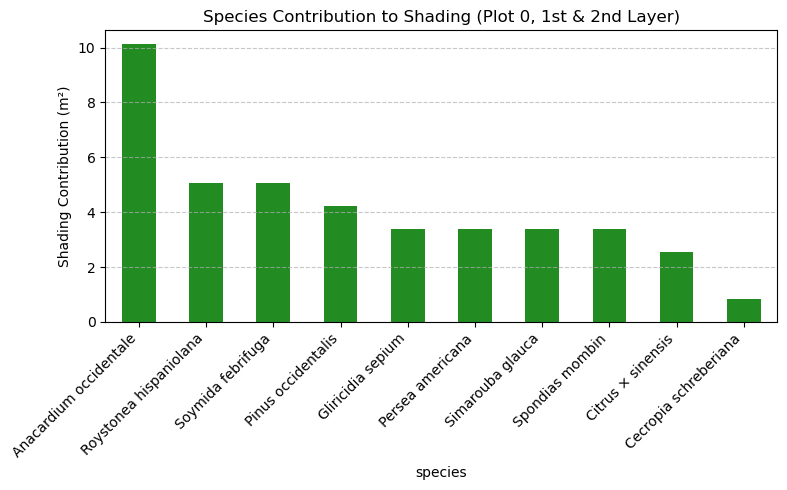

In [9]:
import matplotlib.pyplot as plt

# Filter to first and second layer trees in plot 0
subset = agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
]

# Group by species and sum shading_m2
shading_contrib = (
    subset.groupby("species")["shading_m2"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8, 5))
shading_contrib.plot(kind="bar", color="forestgreen")
plt.ylabel("Shading Contribution (m²)")
plt.title("Species Contribution to Shading (Plot 0, 1st & 2nd Layer)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [10]:
agroforest_df[
    (agroforest_df["plot_index"] == 1)]

,species,n_trees,height_m,height_min_m,height_max_m,type,cover_ratio,role,plot_size_m2,forest_cover,...,system_type,source,geometry,adjusted_cover_ratio,adjusted_cover_area_m2,species_based_cover_area_m2,estimated_forest_cover_area_m2,expected_forest_area_m2,shading_m2,plot_index
25,Soymida febrifuga,3,13.393668,10.0,25.0,1st tree,1.0,mid canopy,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),3.0,240.0,240.0,6506.666667,6506.666667,5.061584,1
26,Roystonea hispaniolana,3,17.828732,10.0,25.0,1st tree,1.0,upper canopy,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),3.0,240.0,240.0,6506.666667,6506.666667,5.061584,1
27,Simarouba glauca,4,9.964920,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),2.0,160.0,160.0,6506.666667,6506.666667,3.374390,1
28,Pinus occidentalis,5,5.037455,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),2.5,200.0,200.0,6506.666667,6506.666667,4.217987,1
29,Cecropia schreberiana,1,15.997407,10.0,25.0,1st tree,0.5,upper canopy,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),0.5,40.0,40.0,6506.666667,6506.666667,0.843597,1
30,Musa × paradisiaca,55,3.312278,0.5,5.0,Shrub,20.0,understory,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),1100.0,88000.0,88000.0,6506.666667,6506.666667,1855.914257,1
31,Cajanus cajan,11,4.463797,0.5,5.0,Shrub,0.5,understory,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),5.5,440.0,440.0,6506.666667,6506.666667,9.279571,1
32,Anacardium occidentale,6,9.212343,5.0,10.0,2nd tree,1.0,mid canopy,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),6.0,480.0,480.0,6506.666667,6506.666667,10.123169,1
33,Citrus × sinensis,3,7.383033,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),1.5,120.0,120.0,6506.666667,6506.666667,2.530792,1
34,Guazuma ulmifolia,8,0.873703,0.5,5.0,Shrub,0.5,understory,8000,81.333333,...,Agroforestry,table,POINT (-71.29392 19.30833),4.0,320.0,320.0,6506.666667,6506.666667,6.748779,1


# load ecocrop, downloaded from here: https://github.com/OpenCLIM/ecocrop
find value per specie

In [11]:
import pandas as pd
from config import ECOCROP_PATH

# Load EcoCrop database
ecocrop = pd.read_csv(ECOCROP_PATH, encoding="latin1")

# Clean EcoCrop species names
ecocrop["species_clean"] = ecocrop["ScientificName"].str.strip().str.lower()

# Select relevant climate and drought-related columns
climate_cols = [
    "species_clean",
    "TMIN", "TOPMN", "TOPMX", "TMAX",
    "RMIN", "ROPMN", "ROPMX", "RMAX",
    "PHOTO", "KTMPR", "KTMP", "CLIZ",
    "DRA", "DRAR"
]
ecocrop_subset = ecocrop[climate_cols]

# Clean and match with agroforest_df
agroforest_df["species_clean"] = agroforest_df["species"].str.strip().str.lower()
agroforest_df = agroforest_df.merge(ecocrop_subset, on="species_clean", how="left")


In [12]:
agroforest_df[
    (agroforest_df["plot_index"] == 1) & (agroforest_df["type"].isin(["1st tree", "2nd tree"]))]

,species,n_trees,height_m,height_min_m,height_max_m,type,cover_ratio,role,plot_size_m2,forest_cover,...,RMIN,ROPMN,ROPMX,RMAX,PHOTO,KTMPR,KTMP,CLIZ,DRA,DRAR
25,Soymida febrifuga,3,13.393668,10.0,25.0,1st tree,1.0,mid canopy,8000,81.333333,...,600.0,800.0,1300.0,1500.0,short day (<12 hours),NaN,NaN,tropical wet & dry (Aw),well (dry spells),"poorly (saturated >50% of year), well (dry spe..."
26,Roystonea hispaniolana,3,17.828732,10.0,25.0,1st tree,1.0,upper canopy,8000,81.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,Simarouba glauca,4,9.964920,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,1200.0,2000.0,3000.0,4000.0,NaN,NaN,NaN,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),"well (dry spells), excessive (dry/moderately dry)"
28,Pinus occidentalis,5,5.037455,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,1300.0,1400.0,1500.0,1600.0,"short day (<12 hours), neutral day (12-14 hour...",NaN,NaN,tropical wet & dry (Aw),well (dry spells),"poorly (saturated >50% of year), well (dry spe..."
29,Cecropia schreberiana,1,15.997407,10.0,25.0,1st tree,0.5,upper canopy,8000,81.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,Anacardium occidentale,6,9.212343,5.0,10.0,2nd tree,1.0,mid canopy,8000,81.333333,...,400.0,750.0,1600.0,4000.0,"short day (<12 hours), neutral day (12-14 hour...",NaN,NaN,"tropical wet & dry (Aw), steppe or semiarid (B...",well (dry spells),"well (dry spells), excessive (dry/moderately dry)"
33,Citrus × sinensis,3,7.383033,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,Spondias mombin,4,7.515933,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,600.0,1000.0,2000.0,2800.0,"short day (<12 hours), neutral day (12-14 hour...",NaN,NaN,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),well (dry spells)
36,Persea americana,4,5.712729,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,300.0,500.0,2000.0,2500.0,NaN,-4.0,-1.0,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),well (dry spells)
37,Gliricidia sepium,4,9.087605,5.0,10.0,2nd tree,0.5,mid canopy,8000,81.333333,...,600.0,1200.0,2300.0,3500.0,short day (<12 hours),-2.0,-1.0,"tropical wet & dry (Aw), tropical wet (Ar)","well (dry spells), excessive (dry/moderately dry)","poorly (saturated >50% of year), well (dry spe..."


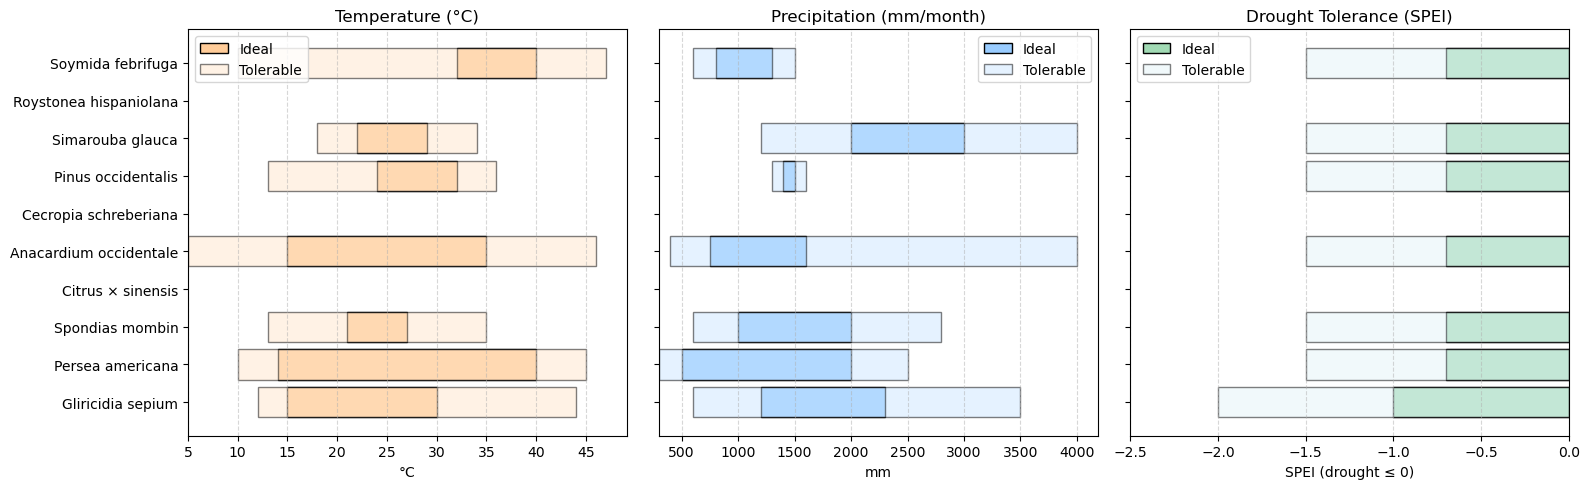

In [13]:
spei_dict = generate_spei_dict_from_dra(agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
])
plot_agroforest_vulnerability(agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
], spei_dict)

### 🔥🌧️ Generating Synthetic Climate Hazards for the Dominican Republic (DR)

This following cell builds synthetic 100-year hazard datasets for **heat (temperature)** and **drought (precipitation)** using the **TerraClimate** dataset and the **CLIMADA** hazard modeling framework. It performs the following steps:

---

#### 1. **Setup and Dataset Paths**
- Two climate scenarios are used:
  - `"historical"`: Historical climate data.
  - `"plus2C"`: Future climate scenario with +2°C warming.
- Files are cropped to the **Dominican Republic** using latitude and longitude bounds.

---

#### 2. **Annual Aggregation**
- Function: `get_annual_aggregates(path)`
  - Loads annual maxima of:
    - `tmin`: daily minimum temperature
    - `tmax`: daily maximum temperature
  - Computes annual max of mean temperature:  
    \[
    t_{\text{mean}} = \frac{t_{\text{max}} + t_{\text{min}}}{2}
    \]
  - Computes annual total **precipitation**.
  - Clips all outputs to DR extent.

---

#### 3. **Extreme Value Sampling (GEV)**
- Function: `generate_gev_sample_field(dataarray, n_years=100)`
  - Fits a **Generalized Extreme Value (GEV)** distribution at each grid point.
  - Draws 100 synthetic samples per pixel to simulate extreme future events.
  - If `invert=True`, the distribution is mirrored (used for **low precipitation** extremes).

---

#### 4. **Hazard Object Creation**
- Function: `create_hazard_from_array(...)`
  - Converts the synthetic yearly fields into **CLIMADA-compatible Hazard objects**.
  - Hazard type:
    - `"TM"` for temperature (`degC`)
    - `"PR"` for precipitation (`mm`)
  - Each year is treated as a separate event.
  - Includes:
    - `intensity` matrix (year × location)
    - `centroids` grid
    - event metadata (IDs, names, dates, frequency)

---

#### 5. **Run Full Pipeline**
- For each scenario:
  - Aggregates the raw climate data.
  - Samples 100 synthetic years for both temperature and precipitation.
  - Builds and stores the corresponding Hazard objects in a dictionary.

```python
hazard_dict = {
    "historical": {
        "TM": Hazard object for temperature,
        "PR": Hazard object for precipitation
    },
    "plus2C": {
        "TM": ...,
        "PR": ...
    }
}


In [14]:
import os
from climada.hazard.base import Hazard
from config import DATA_DIR, TERRACLIMATE_PATHS
from utils_hazards import (
    get_aggregates, compute_spei_3,
    generate_gev_sample_field, create_hazard_from_array
)

# === Settings ===
LAT_BOUNDS_DR = (20.0, 17.5)
LON_BOUNDS_DR = (-72.0, -68.0)
haz_types = ["TM", "PR", "SPEI"]
output_dir = os.path.join(DATA_DIR, "hazards_dominican_republic")
os.makedirs(output_dir, exist_ok=True)

def get_hazard_path(scenario, haz_type):
    return os.path.join(output_dir, f"write_hazard_{scenario}_{haz_type}.hdf5")

def load_hazard_from_file(scenario, haz_type):
    path = get_hazard_path(scenario, haz_type)
    haz = Hazard.from_hdf5(path)
    print(f"📂 Loaded: {path}")
    return haz

def save_hazard_to_file(hazard, scenario, haz_type):
    path = get_hazard_path(scenario, haz_type)
    hazard.write_hdf5(path)
    print(f"💾 Saved: {path}")

# === Main loop ===
hazard_dict = {}

for scenario, path in TERRACLIMATE_PATHS.items():
    print(f"\n🚀 Processing scenario: {scenario}")
    all_exist = all(os.path.exists(get_hazard_path(scenario, haz_type)) for haz_type in haz_types)

    if all_exist:
        print("✅ All hazard files found — skipping computation.")
        hazard_dict[scenario] = {
            haz_type: load_hazard_from_file(scenario, haz_type)
            for haz_type in haz_types
        }
        continue

    print("🧮 Computing hazards...")
    tmean, ppt, ppt_monthly, pet_monthly = get_aggregates(path)

    print("🌵 Computing SPEI...")
    spei_3 = compute_spei_3(ppt_monthly, pet_monthly)
    spei_yearly = spei_3.groupby(spei_3.time.dt.year).min("time")

    print("🎲 Sampling synthetic HOT, DRY, and DRIEST years (GEV)...")
    tmean_100yrs = generate_gev_sample_field(tmean, n_years=100)
    ppt_100yrs = generate_gev_sample_field(ppt, n_years=100, invert=True)
    spei_100yrs = generate_gev_sample_field(spei_yearly, n_years=100, invert=True)

    print("🌍 Creating CLIMADA Hazard objects...")
    haz_tmean = create_hazard_from_array(tmean_100yrs, haz_type="TM", units="degC")
    haz_ppt = create_hazard_from_array(ppt_100yrs, haz_type="PR", units="mm")
    haz_spei = create_hazard_from_array(spei_100yrs, haz_type="SPEI", units="index")

    # Save to disk
    save_hazard_to_file(haz_tmean, scenario, "TM")
    save_hazard_to_file(haz_ppt, scenario, "PR")
    save_hazard_to_file(haz_spei, scenario, "SPEI")

    hazard_dict[scenario] = {
        "TM": haz_tmean,
        "PR": haz_ppt,
        "SPEI": haz_spei
    }

print("\n✅ Done: HOT, DRY & DRIEST hazard generation or loading completed.")



🚀 Processing scenario: plus2C
✅ All hazard files found — skipping computation.
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_plus2C_TM.hdf5
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_plus2C_PR.hdf5
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_plus2C_SPEI.hdf5

🚀 Processing scenario: historical
✅ All hazard files found — skipping computation.
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_historical_TM.hdf5
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_historical_PR.hdf5
📂 Loaded: /Users/szelie/data/unu/hazards_dominican_republic/write_hazard_historical_SPEI.hdf5

✅ Done: HOT, DRY & DRIEST hazard generation or loading completed.


# plotting the shift with climate change:

In [15]:
hazard_dict

{'plus2C': {'TM': <climada.hazard.base.Hazard at 0x31c1cb090>,
  'PR': <climada.hazard.base.Hazard at 0x31bf4be50>,
  'SPEI': <climada.hazard.base.Hazard at 0x31bdbfd90>},
 'historical': {'TM': <climada.hazard.base.Hazard at 0x111b02510>,
  'PR': <climada.hazard.base.Hazard at 0x31a9d5890>,
  'SPEI': <climada.hazard.base.Hazard at 0x31a9b4e10>}}

In [16]:
from climada.util.api_client import Client
client = Client()

# Load historical and future tropical cyclone hazards
tc_hist_proba = client.get_hazard(
    'tropical_cyclone',
    properties={"country_iso3alpha":"DOM", "event_type":"synthetic", "climate_scenario":"None"}
)

tc_future_proba = client.get_hazard(
    'tropical_cyclone',
    properties={"country_iso3alpha":"DOM", "event_type":"synthetic", "climate_scenario":"rcp45", "ref_year": "2060"}
)

# Add to your hazard dictionary
hazard_dict['historical']["TC"] = tc_hist_proba
hazard_dict["plus2C"]['TC'] = tc_future_proba


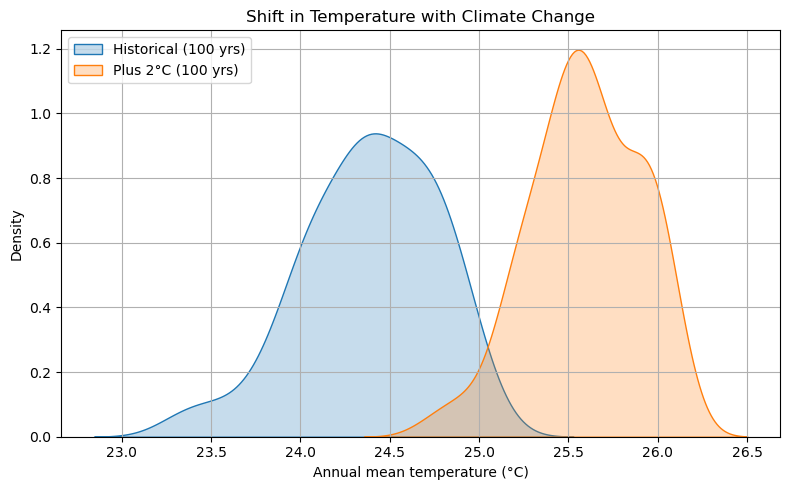

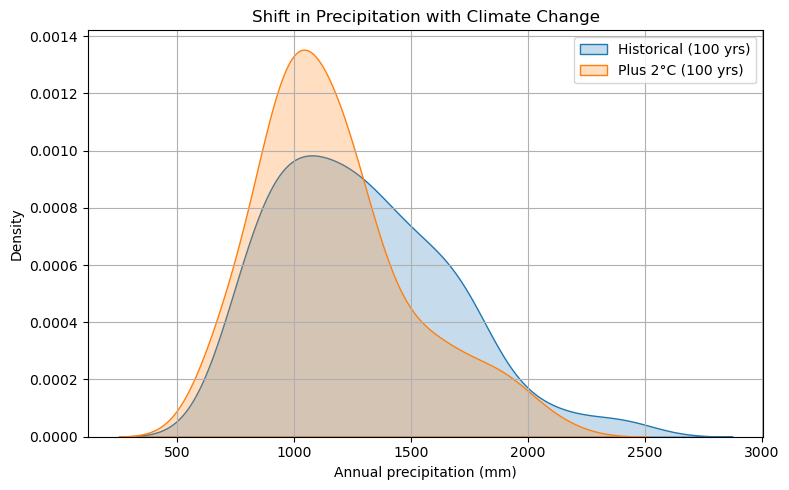

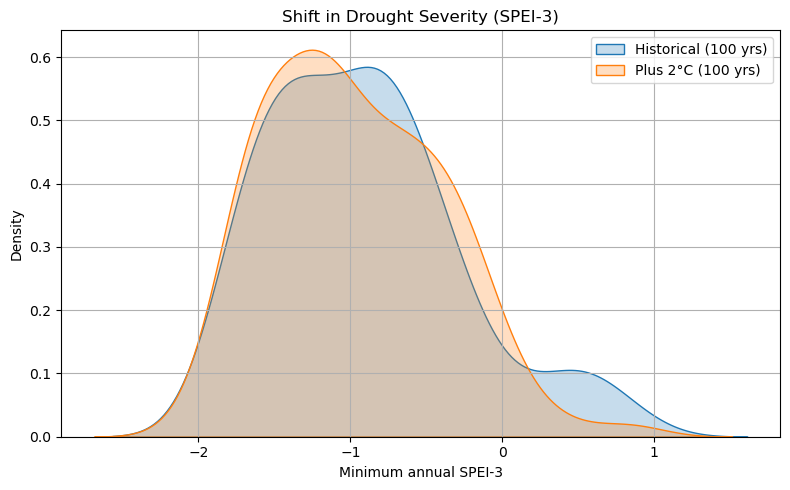

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the location
lat = 19.293583
lon = -71.252111

# Helper to extract intensity at the nearest point
def get_intensity_at_point(hazard, lat, lon):
    dists = np.sqrt((hazard.centroids.lat - lat)**2 + (hazard.centroids.lon - lon)**2)
    idx = dists.argmin()
    return hazard.intensity.toarray()[:, idx]

# Extract values
tmean_hist = get_intensity_at_point(hazard_dict["historical"]["TM"], lat, lon)
tmean_fut  = get_intensity_at_point(hazard_dict["plus2C"]["TM"], lat, lon)

ppt_hist = get_intensity_at_point(hazard_dict["historical"]["PR"], lat, lon)
ppt_fut  = get_intensity_at_point(hazard_dict["plus2C"]["PR"], lat, lon)

spei_hist = get_intensity_at_point(hazard_dict["historical"]["SPEI"], lat, lon)
spei_fut  = get_intensity_at_point(hazard_dict["plus2C"]["SPEI"], lat, lon)

# Plot helper
def plot_kde_comparison(hist_vals, fut_vals, xlabel, title):
    plt.figure(figsize=(8, 5))
    sns.kdeplot(hist_vals, label="Historical (100 yrs)", fill=True)
    sns.kdeplot(fut_vals, label="Plus 2°C (100 yrs)", fill=True)
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot all 3 variables
plot_kde_comparison(tmean_hist, tmean_fut, "Annual mean temperature (°C)", "Shift in Temperature with Climate Change")
plot_kde_comparison(ppt_hist, ppt_fut, "Annual precipitation (mm)", "Shift in Precipitation with Climate Change")
plot_kde_comparison(spei_hist, spei_fut, "Minimum annual SPEI-3", "Shift in Drought Severity (SPEI-3)")


# let's add impact functions based on FAO thresholds:

In [18]:
tmean, ppt, ppt_monthly, pet_monthly = get_aggregates(path)

📂 Loading 38 files for tmin
📂 Loading 38 files for tmax
📂 Loading 38 files for ppt
📂 Loading 38 files for pet


In [19]:
agroforest_df

,species,n_trees,height_m,height_min_m,height_max_m,type,cover_ratio,role,plot_size_m2,forest_cover,...,RMIN,ROPMN,ROPMX,RMAX,PHOTO,KTMPR,KTMP,CLIZ,DRA,DRAR
0,Inga fagifolia single,43,20.986130,10.0,25.0,1st tree,20.0,upper canopy,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mangifera indica single,22,23.177606,10.0,25.0,1st tree,5.0,upper canopy,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Roystonea hispaniolana single,14,NaN,NaN,NaN,Herb,0.5,understory,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Didymopanax morototoni single,5,23.005546,10.0,25.0,1st tree,1.0,upper canopy,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Senna spectabilis single,2,20.902041,10.0,25.0,1st tree,0.5,upper canopy,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Musa × paradisiaca,52,8.129603,5.0,10.0,2nd tree,35.0,mid canopy,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Theobroma cacao,70,4.023991,0.5,5.0,Shrub,10.0,understory,4184,93.000000,...,900.0,1200.0,3000.0,7600.0,"short day (<12 hours), neutral day (12-14 hour...",5.0,0.0,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),well (dry spells)
7,Citrus × sinensis single,11,6.565886,5.0,10.0,2nd tree,2.5,mid canopy,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Citrus × aurantium single,10,7.557372,5.0,10.0,2nd tree,2.5,mid canopy,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Pimenta racemosa single,8,6.586467,5.0,10.0,2nd tree,2.0,mid canopy,4184,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
import copy
from climada.engine import ImpactCalc
from climada.entity import Exposures, ImpactFuncSet
from utils_agroforestry import (
    define_temp_prec_impfs,
    define_tc_impfs,
    define_drought_impfs,
    assign_impact_function_ids,
    generate_spei_dict_from_dra
)

# === STEP 1: Define temperature & precipitation impact functions
impf_set_temp_prec, species_to_temp_id, species_to_prec_id = define_temp_prec_impfs(
    agroforest_df, tmean, ppt
)

# === STEP 2: Define wind (TC) impact functions
impf_set_tc = define_tc_impfs()

# === STEP 3: Define drought (SPEI) impact functions
spei_dict = generate_spei_dict_from_dra(agroforest_df)
impf_set_drought, species_to_drought_id = define_drought_impfs(spei_dict)

# === STEP 4: Assign impact function IDs to exposure data
agroforest_df = assign_impact_function_ids(
    agroforest_df,
    species_to_temp_id,
    species_to_prec_id,
    species_to_drought_id=species_to_drought_id
)



2025-06-11 09:43:17,186 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.
2025-06-11 09:43:17,194 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.


In [21]:
# === STEP 5: Merge all impact functions into a single ImpactFuncSet
impf_set = ImpactFuncSet()

for sub_set in [impf_set_temp_prec, impf_set_tc, impf_set_drought]:
    for haz_funcs in sub_set.get_func().values():  # haz_funcs = {id: ImpactFunc, ...}
        for impf in haz_funcs.values():
            impf_set.append(copy.deepcopy(impf))


2025-06-11 09:43:17,200 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.
2025-06-11 09:43:17,200 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.


In [22]:
for scenario in hazard_dict:
    for haz in hazard_dict[scenario]:
        hazard_dict[scenario][haz].event_id = np.array(hazard_dict[scenario][haz].event_id)

# impact calculation:

In [24]:
from climada.engine import ImpactCalc
from climada.entity import Exposures

# Use shading as value at risk
agroforest_df["value"] = agroforest_df["shading_m2"]

# Filter relevant exposures (e.g. only shade trees in one plot)
exp = Exposures(data=agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
])

# Compute impact for each scenario and hazard type
impact_results = {}

for scenario, hazards in hazard_dict.items():
    hazards['SPEI'].haz_type='DR'
    impact_results[scenario] = {}
    for haz_type, hazard in hazards.items():
        print(f"🔧 Computing impact for {scenario} - {haz_type}")
        impact = ImpactCalc(exp, impf_set, hazard).impact(save_mat=True)
        impact_results[scenario][haz_type] = impact


🔧 Computing impact for plus2C - TM
🔧 Computing impact for plus2C - PR
2025-06-11 09:44:08,557 - climada.hazard.base - WARNING - Impact function id=10 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-06-11 09:44:08,559 - climada.hazard.base - WARNING - Impact function id=12 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-06-11 09:44:08,561 - climada.hazard.base - WARNING - Impact function id=14 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-06-11 09:44:08,564 - climada.hazard.base - WARNING - Impact function id=16 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-06-11 09:44:08,567 - climada.hazard.base - WA

In [25]:
impact_results['historical']['TM'].tot_value

2025-06-11 09:44:08,681 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


41.33627209473183

# Impacts:

2025-06-11 09:44:08,686 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


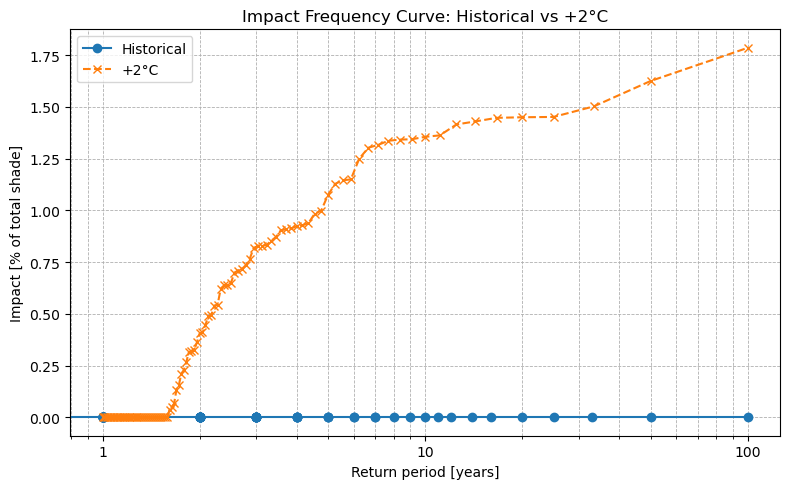

In [26]:
import matplotlib.pyplot as plt

# Get frequency curves
freq_hist = impact_results['historical']['TM'].calc_freq_curve()
freq_sim = impact_results['plus2C']['TM'].calc_freq_curve()

# Total value (same base for percentage calculation)
base_tot_value = impact_results['plus2C']['TM'].tot_value

# Plot
plt.figure(figsize=(8, 5))
plt.plot(freq_hist.return_per.astype('int'), 100 * freq_hist.impact / base_tot_value,
         label="Historical", marker='o', linestyle='-')
plt.plot(freq_sim.return_per, 100 * freq_sim.impact / base_tot_value,
         label="+2°C", marker='x', linestyle='--')

plt.xlabel("Return period [years]")
plt.ylabel("Impact [% of total shade]")
plt.title("Impact Frequency Curve: Historical vs +2°C")
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.6)
plt.xscale("log")
plt.xticks([1, 10, 100], labels=["1", "10", "100"])

plt.tight_layout()
plt.show()


2025-06-11 09:44:08,794 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


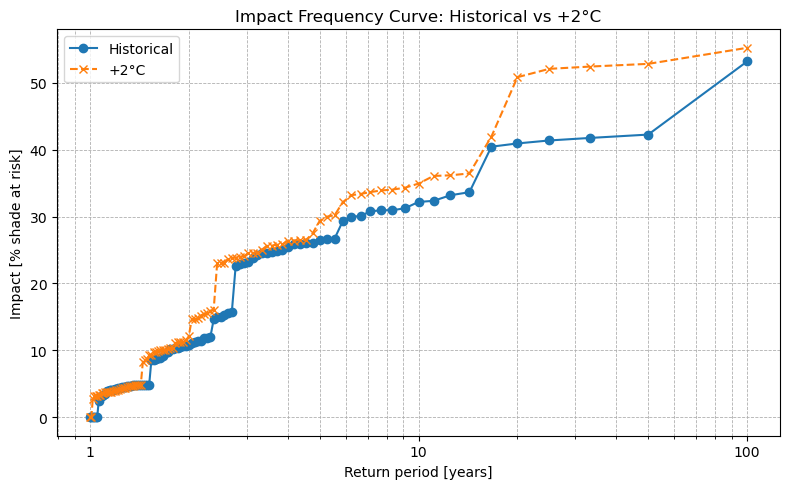

In [27]:
import matplotlib.pyplot as plt

# Get frequency curves
freq_hist = impact_results['historical']['PR'].calc_freq_curve()
freq_sim = impact_results['plus2C']['PR'].calc_freq_curve()

# Total value for normalisation
base_tot_value = impact_results['plus2C']['PR'].tot_value

# Plot
plt.figure(figsize=(8, 5))
plt.plot(freq_hist.return_per, 100 * freq_hist.impact / base_tot_value,
         label="Historical", marker='o', linestyle='-')
plt.plot(freq_sim.return_per, 100 * freq_sim.impact / base_tot_value,
         label="+2°C", marker='x', linestyle='--')

plt.xlabel("Return period [years]")
plt.ylabel("Impact [% shade at risk]")
plt.title("Impact Frequency Curve: Historical vs +2°C")
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.6)
plt.xscale("log")
plt.xticks([1, 10, 100], labels=["1", "10", "100"])

plt.tight_layout()
plt.show()


2025-06-11 09:44:08,901 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


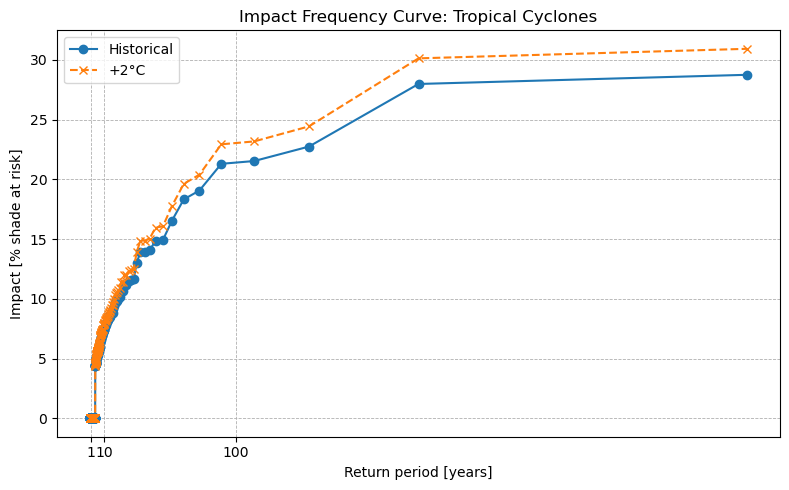

2025-06-11 09:44:09,025 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


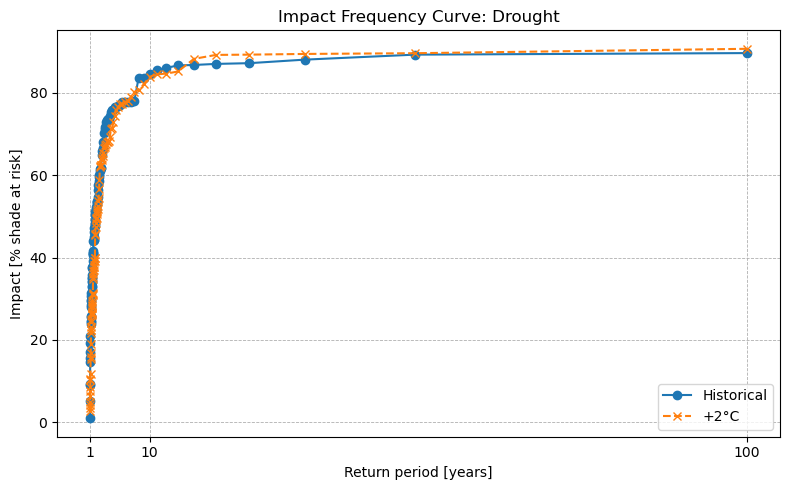

In [28]:
import matplotlib.pyplot as plt

hazards_to_plot = {
    "TC": "Tropical Cyclones",
    "SPEI": "Drought"
}

for haz_code, haz_label in hazards_to_plot.items():
    # Retrieve frequency curves for historical and +2°C
    freq_hist = impact_results['historical'][haz_code].calc_freq_curve()
    freq_sim = impact_results['plus2C'][haz_code].calc_freq_curve()

    # Normalise by total value under +2°C (consistent with your example)
    base_tot_value = impact_results['plus2C'][haz_code].tot_value

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(freq_hist.return_per, 100 * freq_hist.impact / base_tot_value,
             label="Historical", marker='o', linestyle='-')
    plt.plot(freq_sim.return_per, 100 * freq_sim.impact / base_tot_value,
             label="+2°C", marker='x', linestyle='--')

    plt.xlabel("Return period [years]")
    plt.ylabel("Impact [% shade at risk]")
    plt.title(f"Impact Frequency Curve: {haz_label}")
    plt.legend()
    plt.grid(True, which="both", linestyle='--', linewidth=0.6)
    plt.xticks([1, 10, 100], labels=["1", "10", "100"])
    plt.tight_layout()
    plt.show()


# Let's check which species are most at risk:

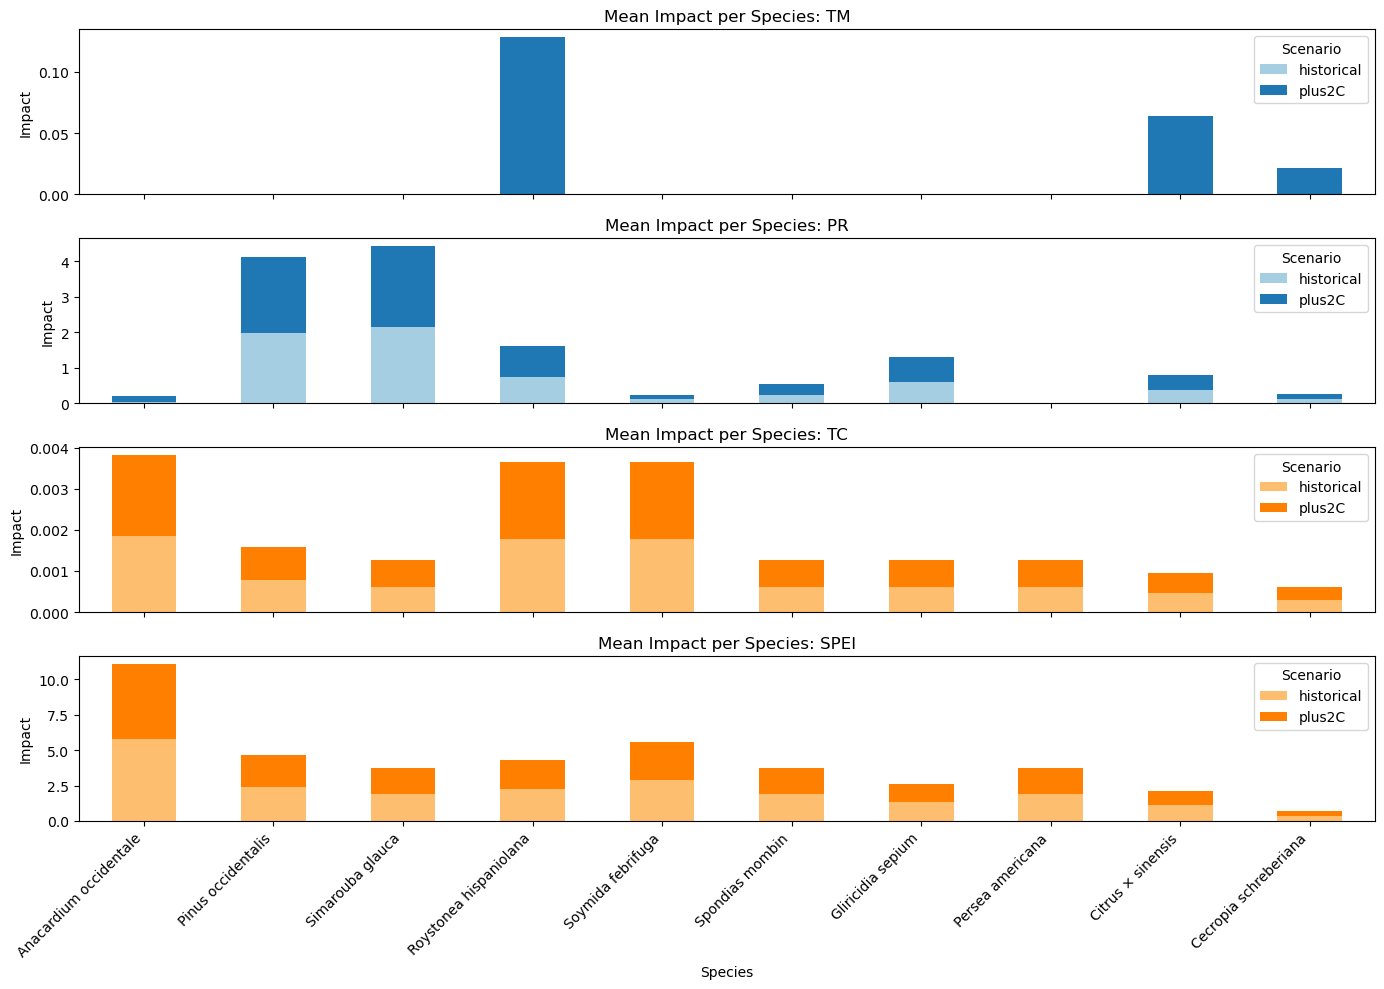

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define scenarios and hazards
scenarios = ["historical", "plus2C"]
hazards = ["TM", "PR", "TC", "SPEI"]

# Filter species (only 1st and 2nd tree layer for a specific plot)
species_names = agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
]["species"].values

# Gather impact data
results = []

for scenario in scenarios:
    for hazard in hazards:
        try:
            imp_mat = impact_results[scenario][hazard].imp_mat  # (time, species)
            mean_impact = imp_mat.mean(axis=0)

            df = pd.DataFrame({
                "species": species_names,
                "mean_impact": np.array(mean_impact).flatten(),
                "hazard": hazard,
                "scenario": scenario
            })
            results.append(df)
        except KeyError:
            print(f"⚠️ Missing data for {scenario} - {hazard}")

# Combine into one DataFrame
impact_df = pd.concat(results, ignore_index=True)

# Get consistent species order based on total impact under plus2C (all hazards)
impact_total = (
    impact_df[impact_df["scenario"] == "plus2C"]
    .groupby("species")["mean_impact"]
    .sum()
    .sort_values(ascending=False)
)
species_order = impact_total.index

# Plotting
n_hazards = len(hazards)
fig, axs = plt.subplots(n_hazards, 1, figsize=(14, 2.5 * n_hazards), sharex=True)

for i, hazard in enumerate(hazards):
    df_plot = impact_df[impact_df["hazard"] == hazard]
    df_pivot = df_plot.pivot(index="species", columns="scenario", values="mean_impact").fillna(0)
    df_pivot = df_pivot.loc[df_pivot.index.intersection(species_order)]

    if df_pivot.empty:
        continue

    df_pivot.loc[species_order].plot(
        kind="bar", stacked=True, ax=axs[i],
        color=["#a6cee3", "#1f78b4"] if hazard in ["TM", "PR"] else ["#fdbf6f", "#ff7f00"]
    )
    axs[i].set_title(f"Mean Impact per Species: {hazard}")
    axs[i].set_ylabel("Impact")
    axs[i].legend(title="Scenario")

axs[-1].set_xlabel("Species")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [30]:
agroforest_df.value

0      229.273625
1       29.325696
2        1.866181
3        1.332986
4        0.266597
5      485.206975
6      186.618067
7        7.331424
8        6.664931
9        4.265556
10       2.399375
11       1.332986
12       1.332986
13    2687.300168
14       5.331945
15       4.265556
16       1.332986
17       1.332986
18     159.958343
19      69.315282
20       1.332986
21       1.332986
22       0.533194
23       1.332986
24       0.533194
25       5.061584
26       5.061584
27       3.374390
28       4.217987
29       0.843597
30    1855.914257
31       9.279571
32      10.123169
33       2.530792
34       6.748779
35       3.374390
36       3.374390
37       3.374390
38    4217.986948
39     168.719478
40       4.217987
41      67.487791
42      16.871948
43      16.871948
44      16.871948
45      16.871948
46      16.871948
47      16.871948
48      16.871948
49      16.871948
Name: value, dtype: float64

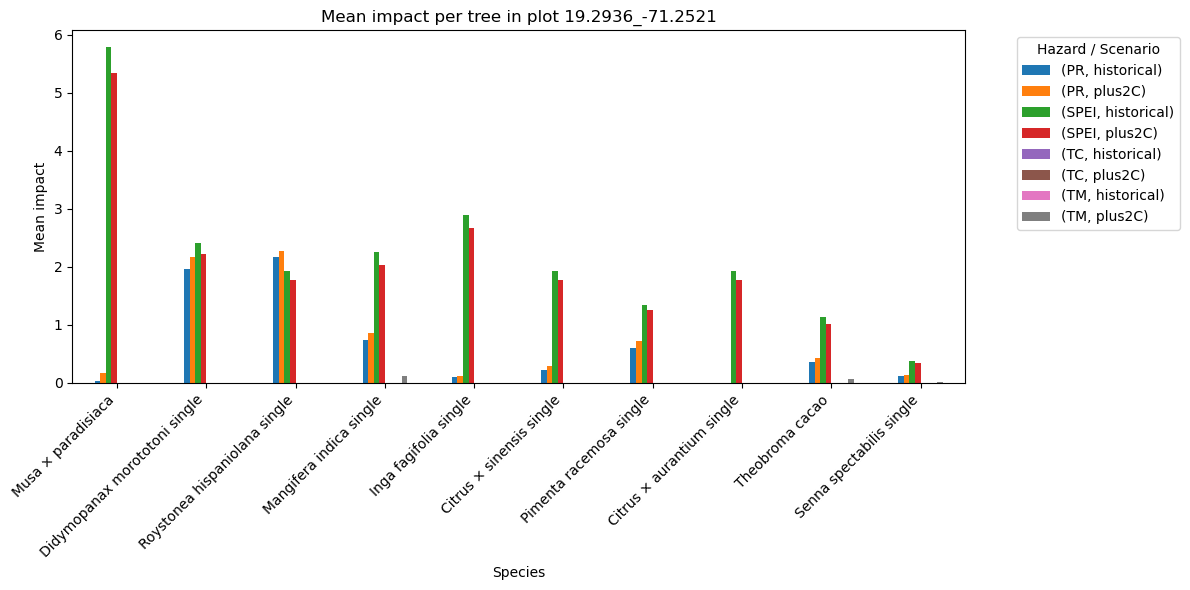

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define scenarios and hazards
scenarios = ["historical", "plus2C"]
hazards = ["TM", "PR", "TC", "SPEI"]

# Step 0: Ensure lat/lon columns exist
agroforest_df["lon"] = agroforest_df.geometry.x
agroforest_df["lat"] = agroforest_df.geometry.y

# Step 1: Create unique plot ID based on rounded coordinates
agroforest_df["plot_id"] = agroforest_df[["lat", "lon"]].round(4).astype(str).agg("_".join, axis=1)

# Step 2: Collect impacts into long-format table
records = []

for scenario in scenarios:
    for hazard in hazards:
        try:
            imp_mat = impact_results[scenario][hazard].imp_mat  # (time, trees)
            mean_impact_per_tree = imp_mat.mean(axis=0).A1  # Flatten matrix to 1D array

            for i, val in enumerate(mean_impact_per_tree):
                records.append({
                    "plot_id": agroforest_df.iloc[i]["plot_id"],
                    "species": agroforest_df.iloc[i]["species"],
                    "lat": agroforest_df.iloc[i]["lat"],
                    "lon": agroforest_df.iloc[i]["lon"],
                    "hazard": hazard,
                    "scenario": scenario,
                    "impact": val,
                    "shade_value": agroforest_df.iloc[i].get("shade_value", None)
                })
        except KeyError:
            print(f"⚠️ Missing impact data for {scenario} - {hazard}")

impact_long_df = pd.DataFrame.from_records(records)

# Step 3: Plot per plot_id
for plot_id, plot_df in impact_long_df.groupby("plot_id"):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Pivot: species x (hazard, scenario)
    pivot = plot_df.pivot_table(index="species", columns=["hazard", "scenario"], values="impact").fillna(0)

    # Sort species by total impact
    pivot["total"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("total", ascending=False)
    pivot.drop(columns="total", inplace=True)

    # Plot grouped bars
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Mean impact per tree in plot {plot_id}")
    ax.set_ylabel("Mean impact")
    ax.set_xlabel("Species")
    ax.legend(title="Hazard / Scenario", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Adaptation

# Adaptation

### 🌳 Tree Replacement Measure – Documentation

This section defines and applies a **climate adaptation measure** for agroforestry systems in the context of climate risk assessment using CLIMADA.

---

#### 🎯 Objective
Simulate a costed adaptation measure that **replaces the most vulnerable tree species** (those with the highest impact under a temperature hazard) with **more resilient alternatives** from a defined replacement pool. The logic ensures that:
- No duplicate species are reintroduced,
- Shading capacity (m²) is preserved,
- Intervention costs are tracked,
- Impacts can later be compared before and after the measure is applied.

---

#### ⚙️ How it Works

1. **Identify vulnerable trees**:
   - Focus on first-layer trees (`type == '1st tree'`) on the main plot (`plot_index == 0`) that have a defined temperature impact function (`impf_TM`).
   - Sort them by vulnerability and remove up to `n_vulnerable_trees`.

2. **Replace with more resilient trees**:
   - Select replacements from a pool of alternative species (excluding those already removed).
   - Match total **shading area** removed with newly planted trees (based on per-tree shading).
   - Ensure only one replacement species is selected (simplified assumption).

3. **Update the Exposures object**:
   - Drop or adjust the original vulnerable rows.
   - Add new rows for replacement trees with adjusted `n_trees`, `shading_m2`, and a modified species name.

4. **Integration with CLIMADA Measure**:
   - The logic is attached to a `Measure` object via `MethodType`, allowing full compatibility with `CostBenefit` and `Impact` modules in CLIMADA.

---

#### 🧪 Output

A summary function displays:
- 🔻 Species removed (with count and shading),
- 🆕 Species added as replacements,
- 📊 Shading removed and added (to validate consistency).

---

💡 *Use this approach to simulate agroforestry adaptation to heat hazards. For precipitation or other hazards, modify the `haz_type` and `impf_` columns accordingly.*


In [210]:
from types import MethodType
import numpy as np
import pandas as pd
import geopandas as gpd
from climada.entity import Exposures, Measure

# === Define Measure ===
replace_species_measure = Measure(
    haz_type="TM",
    name="Replace N vulnerable trees with matched shading (no duplicates)",
    cost=2000,
    color_rgb=np.array([0.1, 0.8, 0.3]),
)

# === Define Measure logic ===
def apply_species_replacement(self, exposures, imp_func_set, hazard):
    df = exposures.gdf.copy()

    # Access replacement settings
    species_pool_df = self.species_pool_df
    n_vulnerable_trees = self.n_vulnerable_trees

    # Select trees to remove
    df_vuln = df[(df['plot_index'] == 0) & (df['type'] == '1st tree') & (df['impf_TM'].notna())].copy()
    species_pool = species_pool_df[
        (species_pool_df['type'] == '1st tree') & 
        (species_pool_df['impf_TM'].notna())
    ].copy()

    if df_vuln.empty or species_pool.empty:
        return exposures, imp_func_set, hazard

    df_vuln = df_vuln.sort_values(by='impf_TM', ascending=False)
    removed_rows, removed_trees, shading_removed, removed_species = [], 0, 0, set()

    for idx, row in df_vuln.iterrows():
        n = row['n_trees']
        if removed_trees + n <= n_vulnerable_trees:
            removed_rows.append((idx, row.copy()))
            removed_trees += n
            shading_removed += row['shading_m2']
            removed_species.add(row['species'])
        else:
            partial_n = n_vulnerable_trees - removed_trees
            if partial_n <= 0:
                break
            per_tree_shading = row['shading_m2'] / n
            partial_row = row.copy()
            partial_row['n_trees'] = partial_n
            partial_row['shading_m2'] = per_tree_shading * partial_n
            removed_rows.append((idx, partial_row))
            removed_trees += partial_n
            shading_removed += partial_row['shading_m2']
            removed_species.add(row['species'])
            break

    if removed_trees == 0:
        return exposures, imp_func_set, hazard

    # Remove rows from exposures
    for idx, row in removed_rows:
        if row['n_trees'] == df.loc[idx, 'n_trees']:
            df = df.drop(index=idx)
        else:
            df.loc[idx, 'n_trees'] -= row['n_trees']
            df.loc[idx, 'shading_m2'] -= row['shading_m2']

    # Remove species already removed from replacement pool
    species_pool = species_pool[~species_pool['species'].isin(removed_species)]
    donor_pool = species_pool.sort_values(by='impf_TM')

    donor_rows = []
    remaining_shading = shading_removed
    for _, donor in donor_pool.iterrows():
        per_tree_shading = donor['shading_m2'] / donor['n_trees']
        n_needed = int(np.ceil(remaining_shading / per_tree_shading))
        donor_row = donor.copy()
        donor_row['n_trees'] = n_needed
        donor_row['shading_m2'] = per_tree_shading * n_needed
        donor_row['plot_index'] = 0
        donor_row['species'] += f' (planted x{n_needed})'
        donor_row['geometry'] = removed_rows[0][1]['geometry']
        donor_rows.append(donor_row)
        break

    new_gdf = gpd.GeoDataFrame(pd.DataFrame(donor_rows), geometry='geometry', crs=exposures.gdf.crs)
    df = pd.concat([df, new_gdf], ignore_index=True)

    return Exposures(df), imp_func_set, hazard

# === Bind method and settings ===
replace_species_measure.apply = MethodType(apply_species_replacement, replace_species_measure)
replace_species_measure.species_pool_df = pool.copy()
replace_species_measure.n_vulnerable_trees = 50

# === Apply the measure ===
exp_orig = Exposures(plot.copy())
exp_modified, _, _ = replace_species_measure.apply(exp_orig.copy(), imp_func_set=None, hazard=None)

# === Summary function ===
def print_species_replacement_summary(exp_orig, exp_modified):
    id_cols = ['plot_index', 'species', 'n_trees', 'shading_m2']
    
    added = exp_modified.gdf[id_cols].merge(
        exp_orig.gdf[id_cols], how='outer', indicator=True
    ).query('_merge == "left_only"').drop(columns=['_merge'])
    
    removed = exp_orig.gdf[id_cols].merge(
        exp_modified.gdf[id_cols], how='outer', indicator=True
    ).query('_merge == "left_only"').drop(columns=['_merge'])
    
    if not removed.empty:
        print("🔻 Removed rows:")
        print(removed)
    else:
        print("✅ No rows removed.")

    if not added.empty:
        print("\n🆕 Added rows:")
        print(added)
    else:
        print("✅ No rows added.")

    print(f"\n📊 Total shading removed: {removed['shading_m2'].sum():.2f}")
    print(f"📊 Total shading added:   {added['shading_m2'].sum():.2f}")

print_species_replacement_summary(exp_orig, exp_modified)


🔻 Removed rows:
   plot_index                  species  n_trees  shading_m2
0           0    Inga fagifolia single       43  229.273625
1           0  Mangifera indica single       22   29.325696

🆕 Added rows:
    plot_index                           species  n_trees  shading_m2
0            0           Mangifera indica single       15   19.994793
24           0  Soymida febrifuga (planted x142)      142  239.581659

📊 Total shading removed: 258.60
📊 Total shading added:   259.58


In [181]:
from climada.engine import ImpactCalc

# 1. Build Exposures (already done)
# exp_orig = ...
# exp_modified = ...

# 2. Calculate impact for original and modified exposures
impact_orig = ImpactCalc(exp_orig, impf_set, hazard_dict['plus2C']['TM']).impact()
impact_mod = ImpactCalc(exp_modified, impf_set, hazard_dict['plus2C']['TM']).impact()

# 3. Print results
print(f"🌡️ Scenario: +2°C")
print(f"Original AAI:      {impact_orig.aai_agg:.2f}")
print(f"Modified AAI:      {impact_mod.aai_agg:.2f}")
print(f"💡 Avoided Impact: {impact_orig.aai_agg - impact_mod.aai_agg:.2f}")


🌡️ Scenario: +2°C
Original AAI:      100.67
Modified AAI:      94.43
💡 Avoided Impact: 6.24


2025-06-11 12:01:21,660 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


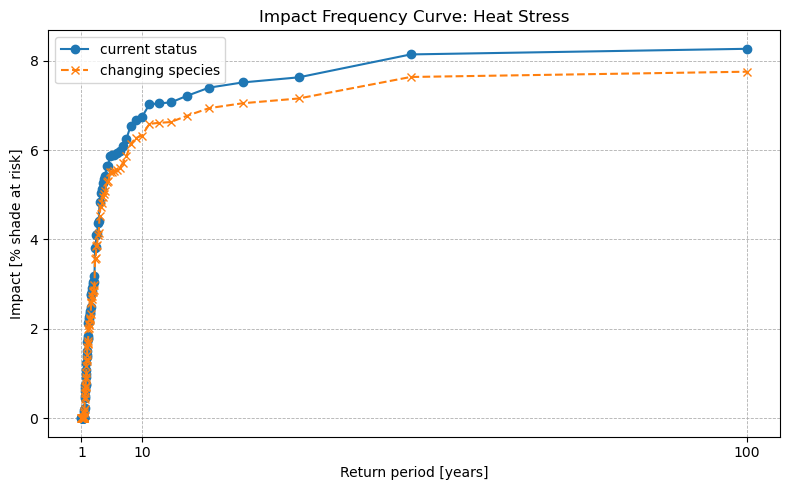

In [230]:
import matplotlib.pyplot as plt



# Retrieve frequency curves for historical and +2°C
freq_hist = impact_orig.calc_freq_curve()
freq_sim = impact_mod.calc_freq_curve()

# Normalise by total value under +2°C (consistent with your example)
base_tot_value = impact_orig.tot_value

# Plot
plt.figure(figsize=(8, 5))
plt.plot(freq_hist.return_per, 100 * freq_hist.impact / base_tot_value,
         label="current status", marker='o', linestyle='-')
plt.plot(freq_sim.return_per, 100 * freq_sim.impact / base_tot_value,
         label="changing species", marker='x', linestyle='--')

plt.xlabel("Return period [years]")
plt.ylabel("Impact [% shade at risk]")
plt.title(f"Impact Frequency Curve: Heat Stress")
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.6)
plt.xticks([1, 10, 100], labels=["1", "10", "100"])
plt.tight_layout()
plt.show()


In [218]:
exp_orig.ref_year = 2000

# To do: implement cost/benefit 
# improve adaptation options for different hazards

In [223]:
# from climada.engine import CostBenefit
# from climada.entity import MeasureSet

# # Define time horizon and discount rates
# year_range = np.arange(2000, 2061)
# annual_discount_stern = np.ones(len(year_range)) * 0.014
# discount_stern = DiscRates(year_range, annual_discount_stern)

# # Entity with NO measure (baseline)
# entity_base = Entity(
#     exposures=exp_orig,
#     impact_func_set=impf_set,
#     disc_rates=discount_stern,
#     measure_set=MeasureSet()  # no measures
# )

# # Entity WITH measure (for future)
# entity_with_measure = Entity(
#     exposures=exp_orig,
#     impact_func_set=impf_set,
#     disc_rates=discount_stern,
#     measure_set=MeasureSet([replace_species_measure])  # includes replacement
# )

# # Run cost-benefit analysis with present and future measure application
# costben_disc = CostBenefit()
# costben_disc.calc(
#     hazard_dict["historical"]["TM"],
#     entity_base,
#     future_year=2060,
#     risk_func=risk_aai_agg,
#     imp_time_depen=1,
#     save_imp=True,
# )
